In [1]:
text = """
Chào mừng các bạn đến với môn “Khám phá dữ liệu với AI và Khai phá tri thức” – nghe tên hơi dài dòng nhưng nội dung thì rất thú vị nha!

Trong môn này, tụi mình sẽ học cách làm việc với dữ liệu – kiểu như mấy bảng số liệu, văn bản, thông tin trên web,... Sau đó dùng AI (kiểu như ChatGPT) để đọc, hiểu và rút ra những điều hay ho từ đống dữ liệu đó.

Mình sẽ học những gì?

Biết cách tìm và thu thập dữ liệu đúng cách.

Làm quen với việc xử lý và làm sạch dữ liệu để dễ phân tích hơn.

Dùng AI để phân tích văn bản, kiểu như cho máy hiểu nội dung tài liệu.

Làm quen với khai phá tri thức – tức là tìm ra thông tin ẩn trong dữ liệu mà người thường khó thấy được.

Học xong để làm gì?
Bạn sẽ có được nền tảng vững về làm việc với dữ liệu và biết cách tận dụng AI để hỗ trợ học tập hoặc làm việc sau này. Nói đơn giản là, biết cách “nói chuyện” với dữ liệu và nhờ AI giúp mình giải quyết vấn đề.
"""

# Library

In [22]:
# !pip install gTTS

In [ ]:
from gtts import gTTS
tts = gTTS(text, lang='vi')
tts.save("tts_gTTS.mp3")

In [ ]:
from pydub import AudioSegment

sound = AudioSegment.from_file("tts_gTTS.mp3")
faster_sound = sound.speedup(playback_speed=1.5)
faster_sound.export("tts_gTTS_fast.mp3", format="mp3")

<_io.BufferedRandom name='hello_fast.mp3'>

# Gemini Google

from google

# T5TTS - https://arxiv.org/abs/2410.06885

In [ ]:
# F5-TTS Text to Speech Notebook
# Hướng dẫn sử dụng F5-TTS để chuyển đổi text thành speech

# 1. Cài đặt các thư viện cần thiết
# Chạy các lệnh này trong terminal hoặc command prompt trước khi chạy notebook

"""
# Cài đặt F5-TTS và các dependencies
pip install torch torchaudio
pip install f5-tts
pip install librosa soundfile

# Hoặc cài đặt từ source
git clone https://github.com/SWivid/F5-TTS.git
cd F5-TTS
pip install -e .
"""

import torch
import torchaudio
import numpy as np
import soundfile as sf
from pathlib import Path
import os
import tempfile
from IPython.display import Audio, display
from f5_tts.api import F5TTS

In [ ]:
class F5TTSProcessor:
    def __init__(self):
        """Initialize F5-TTS processor"""
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"🔧 Use device: {self.device}")
        
        try:
            self.model = F5TTS()
            print("✅ Model F5-TTS was loaded successfully!")
        except Exception as e:
            print(f"❌ Error when loading model: {e}")
            self.model = None
            
    def text_to_speech(self, text, reference_audio_path="audio.wav", output_path="output.wav"):
        if self.model is None:
            raise Exception("Model was not initialized!")

        try:
            if reference_audio_path and os.path.exists(reference_audio_path):
                audio_data = self.model.infer(
                    ref_text=text,
                    gen_text=text,
                    ref_file=reference_audio_path
                )
            else:
                audio_data = self.model.infer(
                    ref_text=text,
                    gen_text=text
                )

            print(f"🎧 Audio data type: {type(audio_data)}")

            if audio_data is None:
                print("❌ audio_data is None. Inference failed.")
                return None

            sf.write(output_path, audio_data, 24000)
            print(f"✅ Created file audio: {output_path}")
            return output_path

        except Exception as e:
            print(f"❌ Error when creating speech: {e}")
            return None

        
    def play_audio(self, audio_path):
        if os.path.exists(audio_path):
            display(Audio(audio_path))
        else:
            print(f"❌ Not found the file audio: {audio_path}")

def demo_f5_tts():
    tts = F5TTSProcessor()
    
    sample_texts = [
        "Xin chào, tôi là F5-TTS. Tôi có thể chuyển đổi văn bản thành giọng nói.",
        "Hello, this is F5-TTS. I can convert text to speech.",
        "F5-TTS is a powerful text-to-speech model with voice cloning capabilities."
    ]
    
    print("🎯 Starting demo F5-TTS...")
    
    for i, text in enumerate(sample_texts):
        print(f"\n📝 Text {i+1}: {text}")
        
        output_file = f"output_sample_{i+1}.wav"
        
        result = tts.text_to_speech(text, output_path=output_file)
        
        if result:
            print(f"🎵 Play audio:")
            tts.play_audio(result)


# 6. Voice Cloning with reference audio
def voice_cloning_demo(text, reference_audio_path):
    """
    Demo voice cloning với audio tham chiếu
    
    Args:
        text (str): Văn bản cần tạo speech
        reference_audio_path (str): Đường dẫn đến file audio mẫu
    """
    if not os.path.exists(reference_audio_path):
        print(f"❌ Không tìm thấy file audio tham chiếu: {reference_audio_path}")
        return None
    
    tts = F5TTSProcessor()
    output_file = "cloned_voice_output.wav"
    
    print(f"🎭 Đang clone voice từ: {reference_audio_path}")
    print(f"📝 Text: {text}")
    
    result = tts.text_to_speech(
        text=text, 
        reference_audio_path=reference_audio_path,
        output_path=output_file
    )
    
    if result:
        print("🎵 Kết quả voice cloning:")
        tts.play_audio(result)
        return result
    return None

if __name__ == "__main__":
    print("🚀 F5-TTS Text to Speech Demo")
    print("=" * 50)
    demo_f5_tts()

In [ ]:
# !pip install vinorm safetensors

# https://github.com/EraX-AI/viF5TTS.git

In [29]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] =  "0" # Tell it which GPU to use (or ignore if you're CPU-bound and patient!)

from vinorm import TTSnorm # Gotta normalize that Vietnamese text first
from viF5TTS.src.model_pruning.f5tts_wrapper import F5TTSWrapper # Our handy wrapper class

In [30]:
from safetensors.torch import load_file
eraX_ckpt_path = load_file("model_45000.safetensors") 

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write
import whisper

# Record audio and save the file WAV
def record_audio_local(filename="audio.wav", duration=10, samplerate=44100):
    print("Start recording...")
    recording = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1, dtype='int16')
    sd.wait()
    write(filename, samplerate, recording)
    print(f"Recording saved to {filename}")

record_audio_local(duration=30) 

In [ ]:
# --- Config ---
# Path to the model checkpoint you downloaded from *this* repo
# MAKE SURE this path points to the actual .pth or .ckpt file!
# eraX_ckpt_path = "path/to/your/downloaded/EraX-Smile-Female-F5-V1.0/model.pth" # <-- CHANGE THIS!

# Path to the voice you want to clone
ref_audio_path = "update_213000_ref.wav" # <-- CHANGE THIS!

# Path to the vocab file from this repo
vocab_file = "vocab.txt" # <-- CHANGE THIS!

# Where to save the generated sound
output_dir = ""

# --- Texts ---
# Text matching the reference audio (helps the model learn the voice). Please make sure it match with the referrence audio!
ref_text = "Thậm chí không ăn thì cũng có cảm giác rất là cứng bụng, chủ yếu là cái phần rốn...trở lên. Em có cảm giác khó thở, và ngủ cũng không ngon, thường bị ợ hơi rất là nhiều"

# The text you want the cloned voice to speak
text_to_generate = "Trong khi đó, tại một chung cư trên địa bàn P.Vĩnh Tuy (Q.Hoàng Mai), nhiều người sống trên tầng cao giật mình khi thấy rung lắc mạnh nên đã chạy xuống sảnh tầng 1. Cư dân tại đây cho biết, họ chưa bao giờ cảm thấy ảnh hưởng của động đất mạnh như hôm nay."

# --- Let's Go! ---
print("Initializing the TTS engine... (Might take a sec)")
tts = F5TTSWrapper(
    vocoder_name="vocos", # Using Vocos vocoder
    ckpt_path=eraX_ckpt_path,
    vocab_file=vocab_file,
    use_ema=False, # ALWAYS False as we converted from .pt to safetensors and EMA (where there is or not) was in there
)

# Normalize the reference text (makes it easier for the model)
ref_text_norm = TTSnorm(ref_text)

# Prepare the output folder
os.makedirs(output_dir, exist_ok=True)

print("Processing the reference voice...")
# Feed the model the reference voice ONCE
# Provide ref_text for better quality, or set ref_text="" to use Whisper for auto-transcription (if installed)
tts.preprocess_reference(
    ref_audio_path=ref_audio_path,
    ref_text=ref_text_norm,
    clip_short=True # Keeps reference audio to a manageable length (~12s)
)
print(f"Reference audio duration used: {tts.get_current_audio_length():.2f} seconds")

# --- Generate New Speech ---
print("Generating new speech with the cloned voice...")

# Normalize the text we want to speak
text_norm = TTSnorm(text_to_generate)

# You can generate multiple sentences easily
# Just add more normalized strings to this list
sentences = [text_norm]

for i, sentence in enumerate(sentences):
    output_path = os.path.join(output_dir, f"generated_speech_{i+1}.wav")

    # THE ACTUAL GENERATION HAPPENS HERE!
    tts.generate(
        text=sentence,
        output_path=output_path,
        nfe_step=32,               # Denoising steps. More = slower but potentially better? (Default: 32)
        cfg_strength=2.0,          # How strongly to stick to the reference voice style? (Default: 2.0)
        speed=1.0,                 # Make it talk faster or slower (Default: 1.0)
        cross_fade_duration=0.15,  # Smooths transitions if text is split into chunks (Default: 0.15)
    )
    print(f"Boom! Audio saved to: {output_path}")

print("\nAll done! Check your output folder.")


# API https://ai.google.dev/gemini-api/docs/speech-generation

In [4]:
import google.generativeai as genai
from dotenv import load_dotenv
import os

secret_key = os.getenv("SECRET_KEY")

d:\Ky 4\vietnamese-speech-chatbox\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# pip install google-genai
from google import genai
from google.genai import types
import wave

# Set up the wave file to save the output:
def wave_file(filename, pcm, channels=1, rate=24000, sample_width=2):
   with wave.open(filename, "wb") as wf:
      wf.setnchannels(channels)
      wf.setsampwidth(sample_width)
      wf.setframerate(rate)
      wf.writeframes(pcm)

client = genai.Client(api_key=secret_key)

response = client.models.generate_content(
   model="gemini-2.5-flash-preview-tts",
   contents=f"Say cheerfully:{text}!",
   config=types.GenerateContentConfig(
      response_modalities=["AUDIO"],
      speech_config=types.SpeechConfig(
         voice_config=types.VoiceConfig(
            prebuilt_voice_config=types.PrebuiltVoiceConfig(
               voice_name='Kore',
            )
         )
      ),
   )
)

data = response.candidates[0].content.parts[0].inline_data.data

file_name='tts_gemini.wav'
wave_file(file_name, data) # Saves the file to current directory

# Limited 

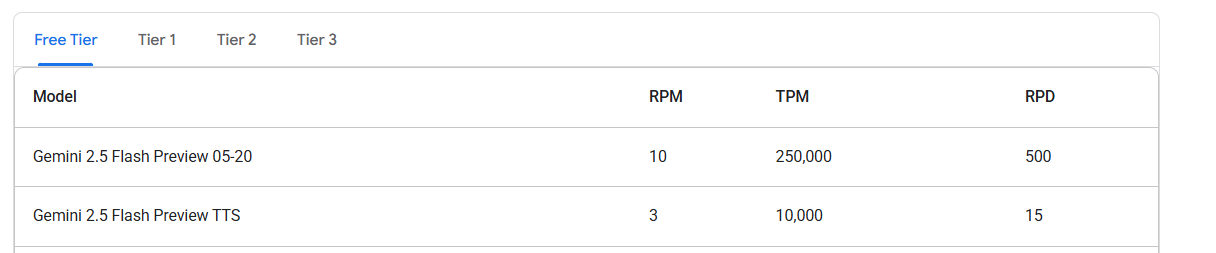